<a href="https://colab.research.google.com/github/naikwadesharvil/mental-health-detection-nlp/blob/main/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# Install required libraries
!pip install transformers datasets torch scikit-learn
!pip install lime shap wandb
!pip install pandas numpy matplotlib seaborn
!pip install nltk emoji contractions

print("All libraries installed successfully!")

All libraries installed successfully!


In [25]:
import torch

print("Checking GPU Availability...")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Device Count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print("\n Setup verification complete!")

Checking GPU Availability...
CUDA Available: True
CUDA Device Count: 1
GPU Name: Tesla T4
GPU Memory: 15.64 GB

 Setup verification complete!


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully! 🚀")

# 🌟 NEW STABLE DATASET URL 🌟
# This is a widely used dataset for detecting depressed/suicidal intention in tweets
url = "https://raw.githubusercontent.com/laxmimerit/twitter-suicidal-intention-dataset/master/twitter-suicidal_data.csv"

# Load the dataset using Pandas
df = pd.read_csv(url)

# This dataset has columns: 'tweet' and 'intention'.
# We will rename 'intention' to 'label' so it works perfectly with the rest of your code!
df = df.rename(columns={'intention': 'label'})

print(f"Dataset loaded! We have {df.shape[0]} rows and {df.shape[1]} columns.")
display(df.head()) # This will show the first 5 rows

Libraries imported successfully! 🚀
Dataset loaded! We have 9119 rows and 2 columns.


,tweet,label
0,my life is meaningless i just want to end my l...,1
1,muttering i wanna die to myself daily for a fe...,1
2,work slave i really feel like my only purpose ...,1
3,i did something on the 2 of october i overdose...,1
4,i feel like no one cares i just want to die ma...,1


Missing values in each column:
 tweet    0
label    0
dtype: int64


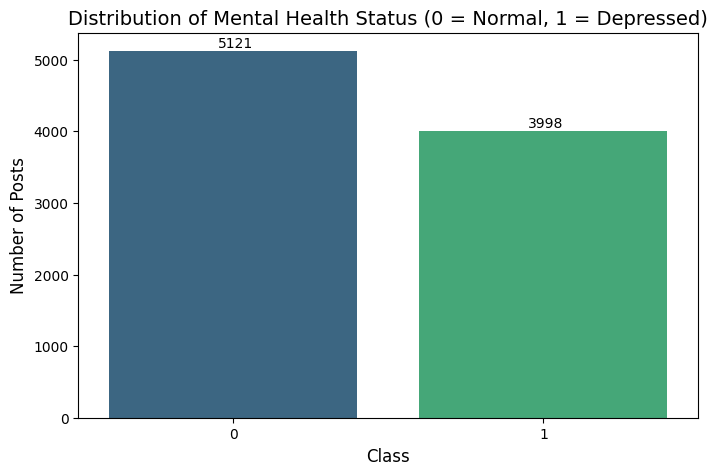

Normal Posts: 56.16%
Depressed Posts: 43.84%


In [27]:
# Check for missing values
print("Missing values in each column:\n", df.isnull().sum())
# Plot the distribution of our classes
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', palette='viridis')
plt.title('Distribution of Mental Health Status (0 = Normal, 1 = Depressed)', fontsize=14)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
# Add exact numbers on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() + 50))
plt.show()
# Calculate exact percentages
normal_pct = (df['label'] == 0).mean() * 100
dep_pct = (df['label'] == 1).mean() * 100
print(f"Normal Posts: {normal_pct:.2f}%")
print(f"Depressed Posts: {dep_pct:.2f}%")

In [28]:
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')
import pandas as pd
import re
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

print(df.columns)

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isna(text):
        return ""

    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return ' '.join(words)

df['clean_text'] = df['tweet'].apply(clean_text)
print(df.head())

Index(['tweet', 'label'], dtype='object')


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                               tweet  label  \
0  my life is meaningless i just want to end my l...      1   
1  muttering i wanna die to myself daily for a fe...      1   
2  work slave i really feel like my only purpose ...      1   
3  i did something on the 2 of october i overdose...      1   
4  i feel like no one cares i just want to die ma...      1   

                                          clean_text  
0  life meaningless want end life badly life comp...  
1  muttering wanna die daily month feel worthless...  
2  work slave really feel like purpose life make ...  
3  something october overdosed felt alone horribl...  
4  feel like one care want die maybe feel less lo...  


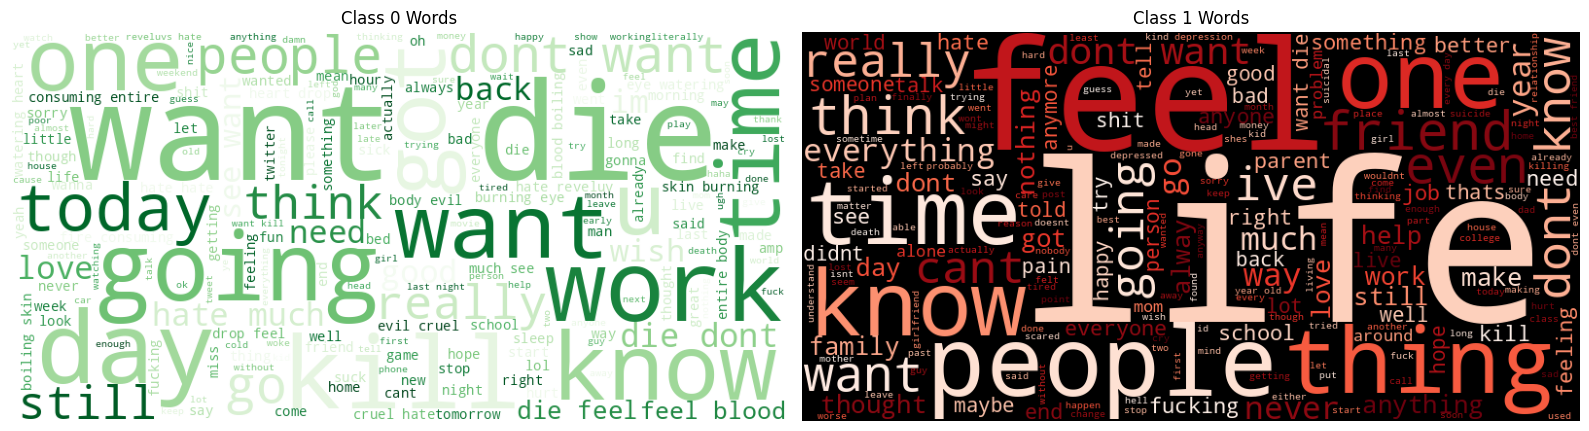

In [29]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Remove empty values
normal_df = df[(df['label'] == 0) & (df['clean_text'] != "")]
depressed_df = df[(df['label'] == 1) & (df['clean_text'] != "")]

normal_text = ' '.join(normal_df['clean_text'])
depressed_text = ' '.join(depressed_df['clean_text'])

plt.figure(figsize=(16, 8))

# Normal / Positive
plt.subplot(1, 2, 1)
if normal_text.strip():
    wc1 = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(normal_text)
    plt.imshow(wc1)
plt.title('Class 0 Words')
plt.axis('off')

# Depressed / Negative
plt.subplot(1, 2, 2)
if depressed_text.strip():
    wc2 = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(depressed_text)
    plt.imshow(wc2)
plt.title('Class 1 Words')
plt.axis('off')

plt.tight_layout()
plt.show()